In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.datasets import make_blobs

In [ ]:
np.random.seed(42)

X, _ = make_blobs(
    n_samples=300, centers=1, cluster_std=0.5, center_box=(0, 0), random_state=42
)
outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.vstack([X, outliers])

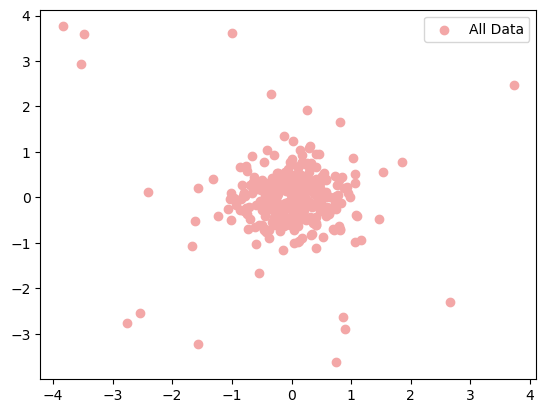

In [12]:
plt.scatter(X[:, 0], X[:, 1], color="#F3A7A7", label="All Data")

plt.legend()
plt.show()

In [13]:
model = IsolationForest(n_estimators=100, contamination=0.06, random_state=42)
preds = model.fit_predict(X)
scores = model.decision_function(X)

inliers = X[preds == 1]
detected_outliers = X[preds == -1]

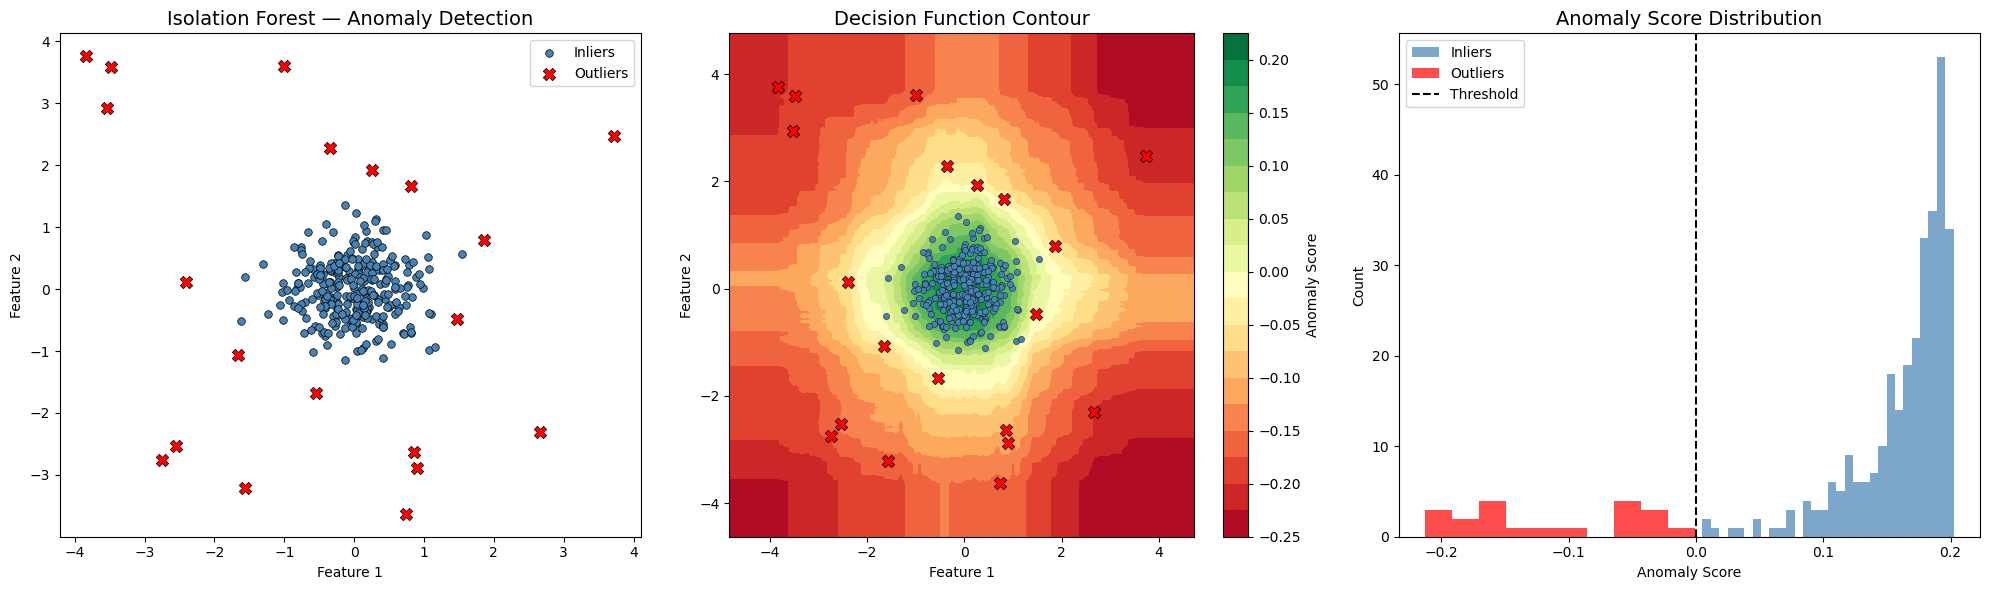

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

axes[0].scatter(
    inliers[:, 0],
    inliers[:, 1],
    c="steelblue",
    s=30,
    edgecolors="k",
    linewidths=0.5,
    label="Inliers",
)
axes[0].scatter(
    detected_outliers[:, 0],
    detected_outliers[:, 1],
    c="red",
    s=80,
    marker="X",
    edgecolors="k",
    linewidths=0.5,
    label="Outliers",
)
axes[0].set_title("Isolation Forest — Anomaly Detection", fontsize=14)
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].legend()

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
    np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200),
)
Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

contour = axes[1].contourf(xx, yy, Z, levels=20, cmap="RdYlGn")
fig.colorbar(contour, ax=axes[1], label="Anomaly Score")
axes[1].scatter(
    inliers[:, 0], inliers[:, 1], c="steelblue", s=20, edgecolors="k", linewidths=0.3
)
axes[1].scatter(
    detected_outliers[:, 0],
    detected_outliers[:, 1],
    c="red",
    s=80,
    marker="X",
    edgecolors="k",
    linewidths=0.5,
)
axes[1].set_title("Decision Function Contour", fontsize=14)
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")

axes[2].hist(scores[preds == 1], bins=30, alpha=0.7, color="steelblue", label="Inliers")
axes[2].hist(scores[preds == -1], bins=10, alpha=0.7, color="red", label="Outliers")
axes[2].axvline(x=0, color="black", linestyle="--", linewidth=1.5, label="Threshold")
axes[2].set_title("Anomaly Score Distribution", fontsize=14)
axes[2].set_xlabel("Anomaly Score")
axes[2].set_ylabel("Count")
axes[2].legend()

plt.tight_layout()
plt.show()

In [14]:
print(f"Total samples: {len(X)}")
print(f"Inliers: {len(inliers)}")
print(f"Outliers detected: {len(detected_outliers)}")

Total samples: 320
Inliers: 300
Outliers detected: 20
